 # MKA-MLF, Lab_07 Convolutional Neural Networks

## Exercise - XOR Gate

## Exercise - Hand-written digits recognition

Create CNN which will process and recognize handwritten digits. For this purposes please use the MNIST database (Modified National Institute of Standards and Technology database) which is a large database of handwritten digits that is commonly used for training various image processing systems.

The datasample of the MNIST datasets can be see in the following picture

![mnist_data_sample.png](attachment:eb3e0d6a-ccb0-499d-9847-ecbc554dbce0.png)

### Task description

In the terms of machine learning, the Hand-written digits recognition can be threated as a multi-class classification problem. This is very important knowledge to structure our model in the correct way (Especially the output-layer, including the number of neurons and activations function and the overall loss function and classification metrics)

### 0. Import libraries

Import the all necessary libraries, you can get inspired by the previous exercises. You can improst the libraries gradually, when do you progressing with the task

In [ ]:
from tensorflow import keras
from keras.models import Sequential
from keras.datasets import mnist
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
###################################

from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.optimizers import Adam
np.random.seed(42)

###################################
font = {'weight' : 'bold',
        'size'   : 12}

matplotlib.rc('font', **font)

### 1. Dataset

#### 1.1 Load Dataset

You can load the dataset using the following code

In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


#### 1.2 Dataset examination

Using the following code, display random images,

In [ ]:
def display_random_images(x_data: np.array, y_data: np.array, count: int = 10) -> None:
  index = np.array(len(x_data))
  selected_ind = np.random.choice(index, count)

  selected_img = x_data[selected_ind]
  selected_labels = y_data[selected_ind]
  concat_img = np.concatenate(selected_img, axis=1)

  plt.figure(figsize=(20,10))
  plt.imshow(concat_img, cmap="gray")

  for id_label, label in enumerate(selected_labels):
    plt.text(14 + 28*id_label, 28*(5/4), label)
  plt.axis('off')
  plt.show()

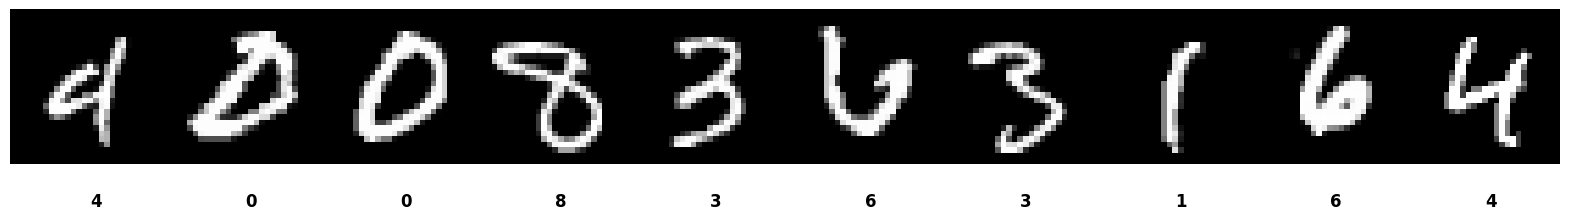

In [ ]:
display_random_images(X_train, y_train)

Examine the dataset. Answer for yourself the following questions:

- What kind of data occurs in our dataset?
- How many data samples do we have in train and test datasets?
- How many colour channels does the input variable have?
- What is the size of the input images?
- What is the necessary preprocessing of the input data X?
- How many classes do we have in target varoable?
- What is the necessary preprocessing of target variable y?

In [ ]:
print("\n===== Answers =====")
print("1. What kind of data occurs in our dataset?")
print("   -> Handwritten digit images (grayscale) and their labels (0~9).")

print("2. How many data samples do we have in train and test datasets?")
print(f"   -> Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

print("3. How many colour channels does the input variable have?")
print("   -> 1 channel (grayscale)")

print("4. What is the size of the input images?")
print(f"   -> {X_train.shape[1]} x {X_train.shape[2]} pixels")

print("5. What is the necessary preprocessing of the input data X?")
print("   -> Convert to float, normalize pixel values to [0,1], and reshape to (28,28,1) for CNN.")

print("6. How many classes do we have in target variable?")
print(f"   -> {len(np.unique(y_train))} classes")

print("7. What is the necessary preprocessing of target variable y?")
print("   -> Labels are integers 0~9; for multi-class classification they can be one-hot encoded.")


===== Answers =====
1. What kind of data occurs in our dataset?
   -> Handwritten digit images (grayscale) and their labels (0~9).
2. How many data samples do we have in train and test datasets?
   -> Train: 60000, Test: 10000
3. How many colour channels does the input variable have?
   -> 1 channel (grayscale)
4. What is the size of the input images?
   -> 28 x 28 pixels
5. What is the necessary preprocessing of the input data X?
   -> Convert to float, normalize pixel values to [0,1], and reshape to (28,28,1) for CNN.
6. How many classes do we have in target variable?
   -> 10 classes
7. What is the necessary preprocessing of target variable y?
   -> Labels are integers 0~9; for multi-class classification they can be one-hot encoded.


#### 1.3 Dataset preprocessing

Perform the necessary data preprocessing. The best way to preprocess the data would be one hot encoding for the target variable and normalization for the input variable (using min-max or z-score normalization)

In [ ]:
# 1. Normalize input data
X_train_scaled = X_train.astype('float32') / 255.0
X_test_scaled  = X_test.astype('float32') / 255.0

# 2. Reshape for CNN (채널 추가)
X_train_scaled = X_train_scaled.reshape(-1, 28, 28, 1)
X_test_scaled  = X_test_scaled.reshape(-1, 28, 28, 1)

# 3. One-hot encoding
from keras.utils import to_categorical

y_train_encoded = to_categorical(y_train, num_classes=10)
y_test_encoded  = to_categorical(y_test, num_classes=10)

### 2. Build the model

In this section, your task will be to define the model architecture. The intial structure can be defined as follows:

Input_layer -> Convolutional_layer(kernel_size=(3,3), no_channels=32) -> Maxpooling_layer(kernel_size=(2, 2)) -> Flatten_layer -> Dense_layer (num_classes)
    
    


#### 2.1 Define the model structure

In [ ]:
model = Sequential()

model.add(Conv2D(
    filters = 32,
    kernel_size = (3,3),
    activation = "relu",
    input_shape = (28, 28, 1)
))

model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())

model.add(Dense(10, activation = "softmax"))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        54,090 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,410 (212.54 KB)

 Trainable params: 54,410 (212.54 KB)

 Non-trainable params: 0 (0.00 B)

#### 2.2 Compile the model

Build the model, use the relevant metrics, optimizer and loss function. While choosing the metrics and loss function, consider fact that we are are trying to solve the multiclass classification problem

In [ ]:
loss = "categorical_crossentropy"
metrics = ["accuracy"]
learning_rate = 0.001

optimizer = Adam(learning_rate=learning_rate)

model.compile(optimizer=optimizer, loss=loss, metrics=metrics)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        54,090 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,410 (212.54 KB)

 Trainable params: 54,410 (212.54 KB)

 Non-trainable params: 0 (0.00 B)

### 3. Training stage

#### 3.1 Model training

train your model, define the relevant hyperparameters (no. epochs, batch_size), use 20p of the training data for validation

In [ ]:
history = model.fit(
    X_train_scaled, y_train_encoded,
    validation_split=0.2,
    epochs=10,
    batch_size=128
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 21s 53ms/step - accuracy: 0.8889 - loss: 0.4032 - val_accuracy: 0.9503 - val_loss: 0.1845
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 48ms/step - accuracy: 0.9577 - loss: 0.1480 - val_accuracy: 0.9704 - val_loss: 0.1138
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 22s 51ms/step - accuracy: 0.9733 - loss: 0.0969 - val_accuracy: 0.9753 - val_loss: 0.0888
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 48ms/step - accuracy: 0.9793 - loss: 0.0757 - val_accuracy: 0.9786 - val_loss: 0.0784
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 20s 53ms/step - accuracy: 0.9819 - loss: 0.0639 - val_accuracy: 0.9791 - val_loss: 0.0717
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - accuracy: 0.9841 - loss: 0.0562 - val_accuracy: 0.9806 - val_loss: 0.0670
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step - accuracy: 0.9852 - loss: 0.0504 - val_accuracy: 0.9802 - val_loss: 0.0643
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - accuracy: 0.9868 - loss: 0.0452 - 

#### 3.1 Model Evaluation on validation data

Plot the development of the training and validation loss, and training and validation metrics.

Test loss: 0.053881123661994934
Test accuracy: 98.34 %


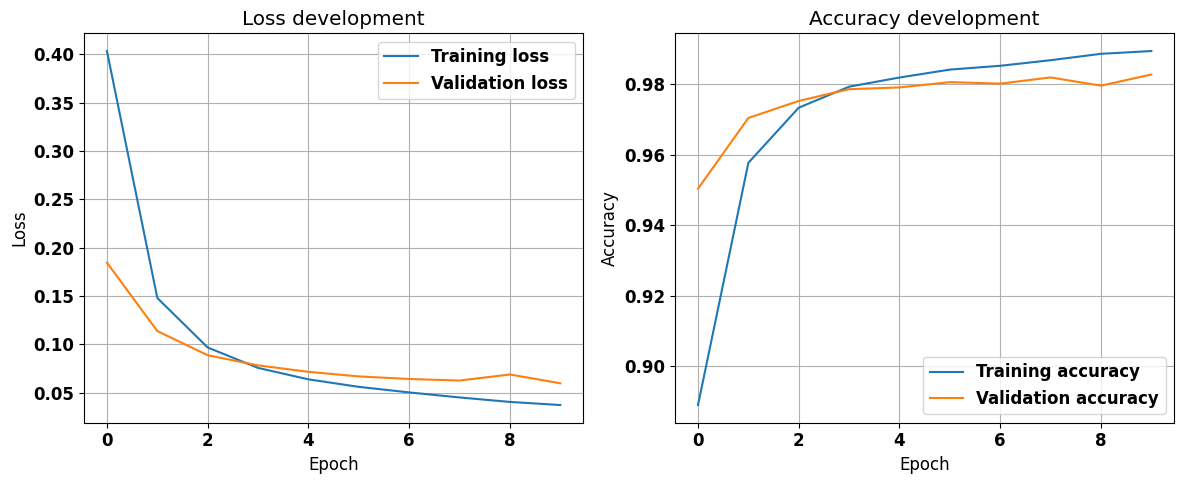

In [ ]:
score = model.evaluate(X_test_scaled, y_test_encoded, verbose=0)
print('Test loss:', score[0])
print(f'Test accuracy: {score[1] * 100:.2f} %')

plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('Loss development')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.title('Accuracy development')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


### 4. Model evaluation

Evaluate the model on the testing dataset using the relevant metrics. Use the confusion metrics as the one of the metrics.

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

Confusion Matrix:
[[ 976    0    0    0    0    0    2    1    1    0]
 [   0 1130    1    2    1    0    0    0    1    0]
 [   3    4 1010    1    2    0    0    7    4    1]
 [   1    0    2  995    0    4    0    4    4    0]
 [   0    1    0    0  976    0    0    0    0    5]
 [   2    0    1    5    0  876    4    0    2    2]
 [   8    2    0    0    4    3  938    0    3    0]
 [   0    3   11    2    1    0    0 1004    2    5]
 [   7    0    3    3    3    1    1    3  949    4]
 [   4    1    0    1   12    1    0    8    2  980]]


<Figure size 800x800 with 0 Axes>

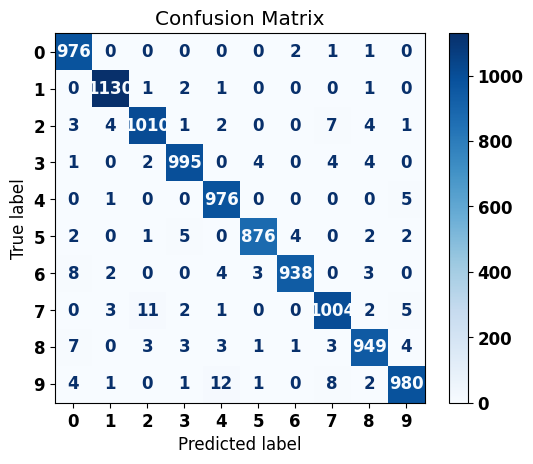

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

y_pred_prob = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test_encoded, axis=1)

# 3. Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print(cm)

# 4. Plot confusion matrix
plt.figure(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.show()

### 5. Hyperparameter tunning and regularization techniques

When your code is ready and fully functional, try several changes in the hyperparameters and see how they influence the testing metrics. Try changes in the network structure. You can also try adding regularization techniques such as L1, L2, and Dropout. Based on the development of training and validation loss, try to identify overfitting and avoid it

In [ ]:
def build_model(conv_filters=32, dense_units=10, dropout_rate=0.0,
                learning_rate=0.001, reg=None, num_conv_layers=1):
    model = Sequential()

    model.add(Conv2D(conv_filters, (3,3), activation='relu', input_shape=(28, 28, 1)))
    model.add(MaxPooling2D((2,2)))

    if num_conv_layers == 2:
        model.add(Conv2D(64, (3,3), activation='relu'))
        model.add(MaxPooling2D((2,2)))

    model.add(Flatten())

    if dense_units != 10:
        if reg == 'l1':
            model.add(Dense(dense_units, activation='relu', kernel_regularizer=l1(0.001)))
        elif reg == 'l2':
            model.add(Dense(dense_units, activation='relu', kernel_regularizer=l2(0.001)))
        else:
            model.add(Dense(dense_units, activation='relu'))

        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))

    model.add(Dense(10, activation='softmax'))

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

def run_experiment(param_name, param_values, fixed_epochs=10, batch_size=128):
    histories = {}
    results = {}

    for value in param_values:
        print(f"\n===== {param_name} = {value} =====")

        if param_name == 'epochs':
            model = build_model()
            history = model.fit(
                X_train_scaled, y_train_encoded,
                validation_split=0.2,
                epochs=value,
                batch_size=batch_size,
                verbose=0
            )

        elif param_name == 'batch_size':
            model = build_model()
            history = model.fit(
                X_train_scaled, y_train_encoded,
                validation_split=0.2,
                epochs=fixed_epochs,
                batch_size=value,
                verbose=0
            )

        elif param_name == 'learning_rate':
            model = build_model(learning_rate=value)
            history = model.fit(
                X_train_scaled, y_train_encoded,
                validation_split=0.2,
                epochs=fixed_epochs,
                batch_size=batch_size,
                verbose=0
            )

        elif param_name == 'dropout_rate':
            model = build_model(dense_units=128, dropout_rate=value)
            history = model.fit(
                X_train_scaled, y_train_encoded,
                validation_split=0.2,
                epochs=fixed_epochs,
                batch_size=batch_size,
                verbose=0
            )

        elif param_name == 'dense_units':
            model = build_model(dense_units=value)
            history = model.fit(
                X_train_scaled, y_train_encoded,
                validation_split=0.2,
                epochs=fixed_epochs,
                batch_size=batch_size,
                verbose=0
            )

        elif param_name == 'conv_filters':
            model = build_model(conv_filters=value)
            history = model.fit(
                X_train_scaled, y_train_encoded,
                validation_split=0.2,
                epochs=fixed_epochs,
                batch_size=batch_size,
                verbose=0
            )

        elif param_name == 'num_conv_layers':
            model = build_model(dense_units=128, num_conv_layers=value, dropout_rate=0.3)
            history = model.fit(
                X_train_scaled, y_train_encoded,
                validation_split=0.2,
                epochs=fixed_epochs,
                batch_size=batch_size,
                verbose=0
            )

        elif param_name == 'regularization':
            model = build_model(dense_units=128, reg=value)
            history = model.fit(
                X_train_scaled, y_train_encoded,
                validation_split=0.2,
                epochs=fixed_epochs,
                batch_size=batch_size,
                verbose=0
            )

        score = model.evaluate(X_test_scaled, y_test_encoded, verbose=0)

        print(f"Test loss: {score[0]:.4f}")
        print(f"Test accuracy: {score[1]*100:.2f}%")

        histories[value] = history
        results[value] = score[1]

    return histories, results

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 468,202 (1.79 MB)

 Trainable params: 468,010 (1.79 MB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 255s 644ms/step - accuracy: 0.8021 - loss: 0.5929 - val_accuracy: 0.9695 - val_loss: 0.3685 - learning_rate: 0.0010
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 251s 618ms/step - accuracy: 0.9378 - loss: 0.1993 - val_accuracy: 0.9862 - val_loss: 0.0503 - learning_rate: 0.0010
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 269s 638ms/step - accuracy: 0.9549 - loss: 0.1452 - val_accuracy: 0.9882 - val_loss: 0.0445 - learning_rate: 0.0010
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 239s 638ms/step - accuracy: 0.9622 - loss: 0.1199 - val_accuracy: 0.9876 - val_loss: 0.0490 - learning_rate: 0.0010
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 239s 637ms/step - accuracy: 0.9702 - loss: 0.0971 - val_accuracy: 0.9892 - val_loss: 0.0360 - learning_rate: 0.0010
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 231s 616ms/step - accuracy: 0.9731 - loss: 0.0854 - val_accuracy: 0.9912 - val_loss: 0.0319 - learning_rate: 0.0010
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 238s 634ms/step - accura

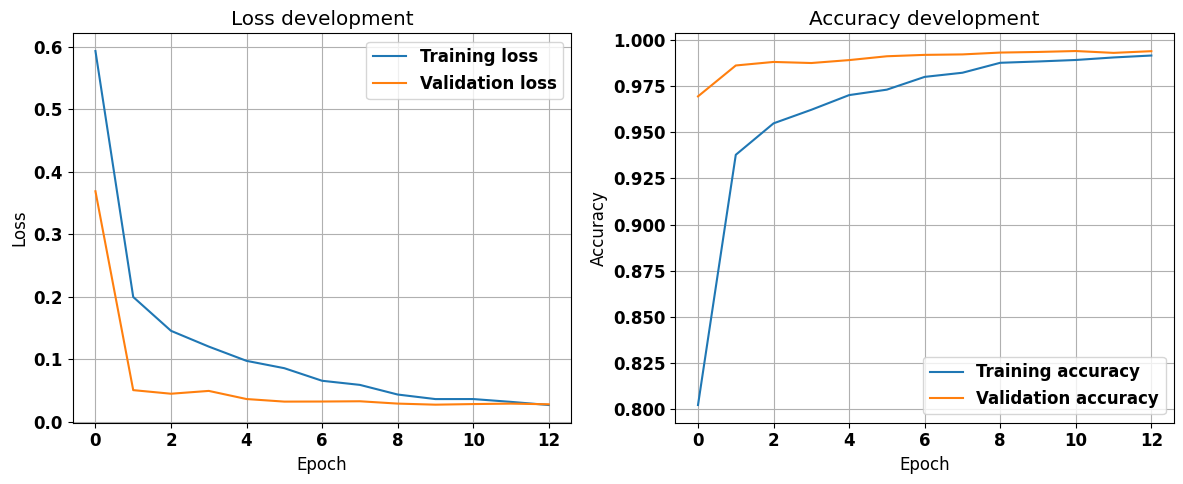

Test loss: 0.017254209145903587
Test accuracy: 99.47 %


In [ ]:
from keras.layers import BatchNormalization
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

model = Sequential()

model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1), padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

# Compile
learning_rate = 0.001

model.compile(
    optimizer=Adam(learning_rate=learning_rate),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

# Train
history = model.fit(
    X_train_scaled,
    y_train_encoded,
    validation_split=0.2,
    epochs=15,
    batch_size=128,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Validation curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('Loss development')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.title('Accuracy development')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Final test evaluation
score = model.evaluate(X_test_scaled, y_test_encoded, verbose=0)
print('Test loss:', score[0])
print(f'Test accuracy: {score[1] * 100:.2f} %')